# Knoxis — Investigating the Train/Test Distribution Shift

The trained Random Forest model performed far worse than expected —
essentially predicting QUIET for almost every window, regardless of the
true class. This notebook investigates **why**, testing two candidate
explanations:

1. **Class frequency shift** — did the relative frequency of B/C/M/X
   flares change between the training period and the test period (e.g.
   a real solar-cycle effect)?
2. **Covariate shift** — for the *same* class, do the feature values
   themselves look different between the two periods? This is the more
   serious possibility: class weighting cannot fix this, since the
   model would have learned "what M-class looks like" from data that no
   longer represents current conditions.

**Before running:** set `MASTER_TABLE_PATH` below to your real
`master_training_table.parquet`.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

MASTER_TABLE_PATH = "pipeline/master_training_table.parquet"  # <-- set this to your real file
TRAIN_TEST_CUTOFF = pd.Timestamp("2026-01-31", tz="UTC")  # <-- matches your actual training run

FEATURE_COLUMNS = [
    "solexs_mean", "solexs_slope", "solexs_std",
    "hel1os_mean", "hel1os_slope",
    "hardness_ratio", "hr_rate_of_change",
    "peak_to_mean_ratio", "hel1os_saturation_fraction",
]

CLASS_COLORS = {"QUIET": "#9CA3AF", "B": "#93C5FD", "C": "#60A5FA", "M": "#F59E0B", "X": "#DC2626"}

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [5]:
df = pd.read_parquet(MASTER_TABLE_PATH)
if df.index.name != "timestamp" and "timestamp" in df.columns:
    df = df.set_index("timestamp")
df = df.sort_index()
df["label_letter"] = df["label_class"].apply(lambda c: "QUIET" if c == "QUIET" else c[0])
df["year_month"] = df.index.tz_localize(None).to_period("M") if df.index.tz is not None else df.index.to_period("M")

print(f"Total rows: {len(df):,}")
print(f"Date range: {df.index.min()} -> {df.index.max()}")
print(f"\nOverall class distribution:")
print(df["label_letter"].value_counts())

Total rows: 226,656
Date range: 2024-02-01 00:00:00+00:00 -> 2026-08-01 23:55:00+00:00

Overall class distribution:
label_letter
QUIET    152993
C         55761
M         13100
B          3888
X           914
Name: count, dtype: int64


## 1. Monthly Class Frequency

If flare activity genuinely follows the solar cycle, we'd expect a
**smooth, gradual trend** in class frequency over the 2.5-year span.
An **abrupt jump** at a specific point would instead suggest something
pipeline-related rather than a real physical change.

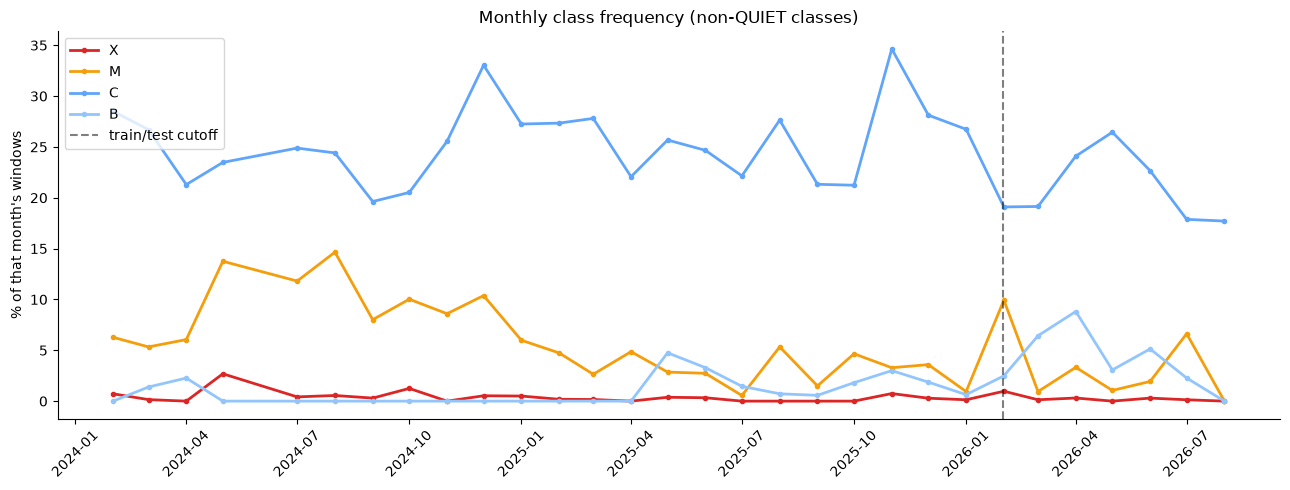

label_letter,X,M,C,B
year_month,,,,
2024-02-01,0.72,6.27,28.51,0.00
2024-03-01,0.15,5.33,26.70,1.39
2024-04-01,0.00,6.05,21.30,2.27
2024-05-01,2.69,13.75,23.48,0.00
2024-07-01,0.42,11.81,24.88,0.00
2024-08-01,0.56,14.65,24.41,0.00
2024-09-01,0.30,8.01,19.63,0.00
2024-10-01,1.25,10.02,20.52,0.00
2024-11-01,0.00,8.60,25.55,0.00


In [6]:
monthly = df.groupby(["year_month", "label_letter"]).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100
monthly_pct.index = monthly_pct.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
for cls in ["X", "M", "C", "B"]:
    if cls in monthly_pct.columns:
        ax.plot(monthly_pct.index, monthly_pct[cls], label=cls, color=CLASS_COLORS[cls], linewidth=2, marker="o", markersize=3)

cutoff_naive = TRAIN_TEST_CUTOFF.tz_localize(None) if TRAIN_TEST_CUTOFF.tz is not None else TRAIN_TEST_CUTOFF
ax.axvline(cutoff_naive, color="black", linestyle="--", alpha=0.5, label="train/test cutoff")
ax.set_ylabel("% of that month's windows")
ax.set_title("Monthly class frequency (non-QUIET classes)")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display_cols = [c for c in ["X", "M", "C", "B"] if c in monthly_pct.columns]
monthly_pct[display_cols].round(2)

## 2. NaN Feature Rate Over Time

Checks whether data quality (fraction of windows dropped for missing
features) is roughly uniform across the whole range, or concentrated in
a specific period — which could independently explain part of any
observed shift.

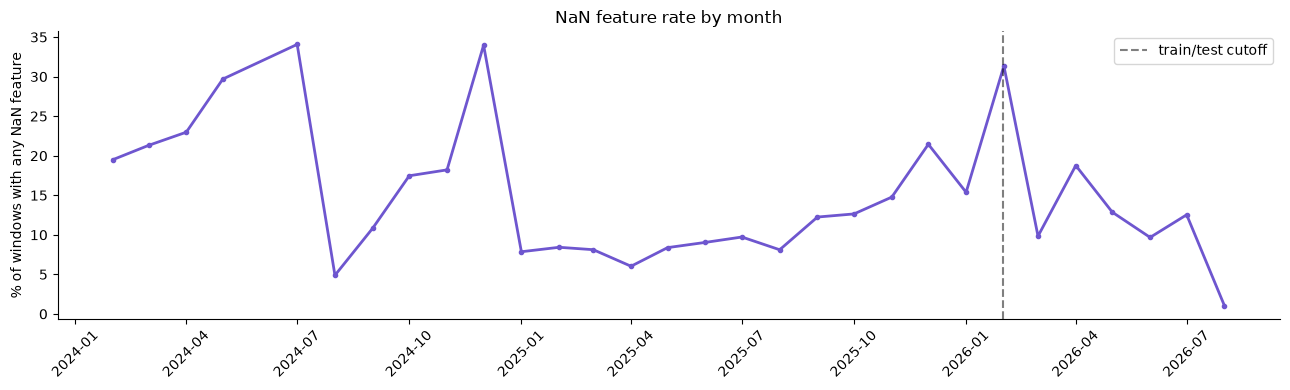

In [7]:
df["any_nan"] = df[FEATURE_COLUMNS].isna().any(axis=1)
nan_by_month = (df.groupby("year_month")["any_nan"].mean() * 100)
nan_by_month.index = nan_by_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(nan_by_month.index, nan_by_month.values, color="#6E56CF", linewidth=2, marker="o", markersize=3)
ax.axvline(cutoff_naive, color="black", linestyle="--", alpha=0.5, label="train/test cutoff")
ax.set_ylabel("% of windows with any NaN feature")
ax.set_title("NaN feature rate by month")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Feature Values for the Same Class: Early vs. Late Period

**This is the most important check.** For each flare class, do the
feature values themselves look statistically different before vs. after
the train/test cutoff? Large differences here indicate a genuine
covariate shift — a change in what a given class actually *looks like*
in the data — which class weighting cannot fix.

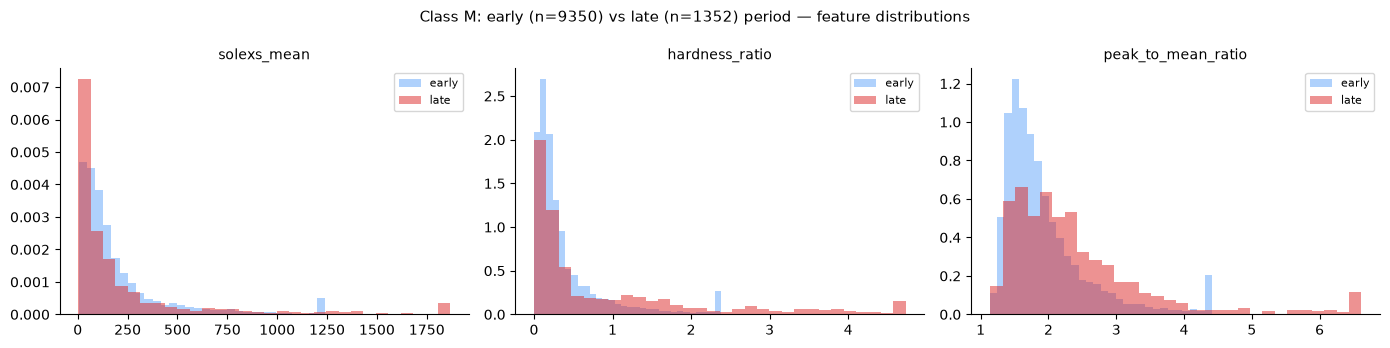


--- Class M: full feature comparison ---


,early_median,late_median,pct_change
solexs_mean,117.4339,80.3428,-31.5847
solexs_slope,-0.0006,-0.0006,0.0000
solexs_std,22.7902,20.3279,-10.8044
hel1os_mean,25.3875,24.7236,-2.6150
hel1os_slope,-0.0250,-0.0822,-228.8889
hardness_ratio,0.2137,0.3059,43.1095
hr_rate_of_change,0.0000,0.0000,100.3386
peak_to_mean_ratio,1.7488,2.1290,21.7375
hel1os_saturation_fraction,0.0000,0.0000,NaN


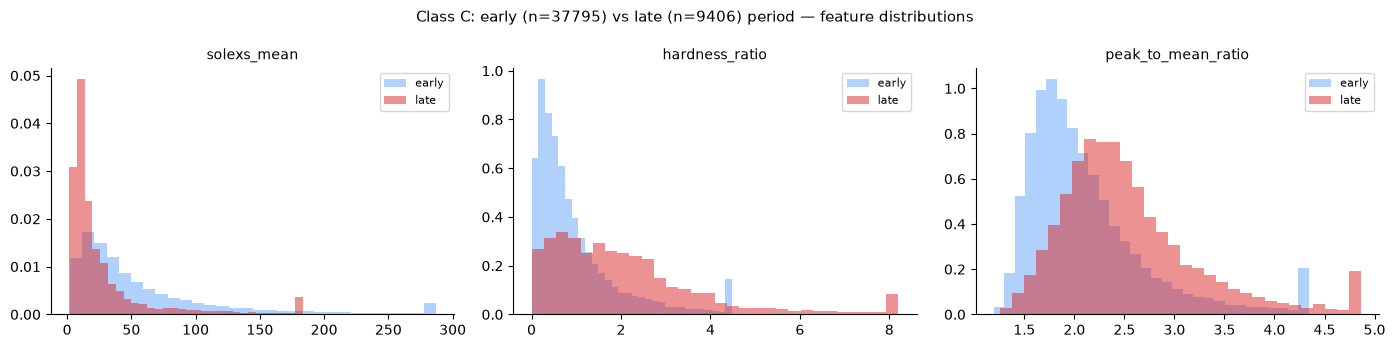


--- Class C: full feature comparison ---


,early_median,late_median,pct_change
solexs_mean,37.2394,14.0169,-62.3600
solexs_slope,-0.0006,-0.0006,0.0000
solexs_std,8.5267,4.6124,-45.9067
hel1os_mean,24.0267,23.9711,-0.2312
hel1os_slope,-0.0206,-0.0128,37.8378
hardness_ratio,0.6362,1.6972,166.7865
hr_rate_of_change,0.0000,0.0000,199.5905
peak_to_mean_ratio,1.9590,2.3976,22.3899
hel1os_saturation_fraction,0.0000,0.0000,NaN


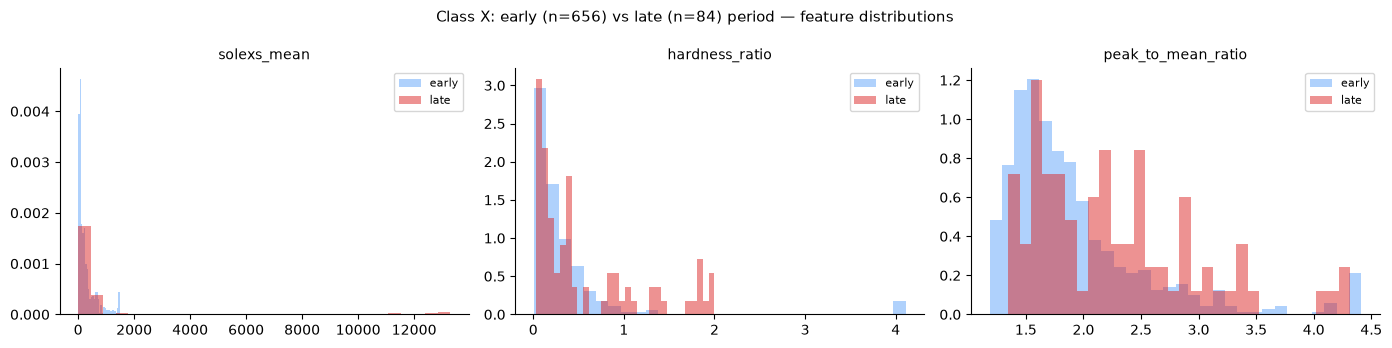


--- Class X: full feature comparison ---


,early_median,late_median,pct_change
solexs_mean,145.5997,73.3378,-49.6306
solexs_slope,-0.0011,0.0075,775.0000
solexs_std,32.5755,31.0092,-4.8084
hel1os_mean,24.9947,24.4942,-2.0026
hel1os_slope,-0.1492,0.3472,332.7747
hardness_ratio,0.1961,0.3341,70.3505
hr_rate_of_change,0.0000,-0.0000,-4959.6376
peak_to_mean_ratio,1.7290,2.1433,23.9641
hel1os_saturation_fraction,0.0000,0.0000,NaN


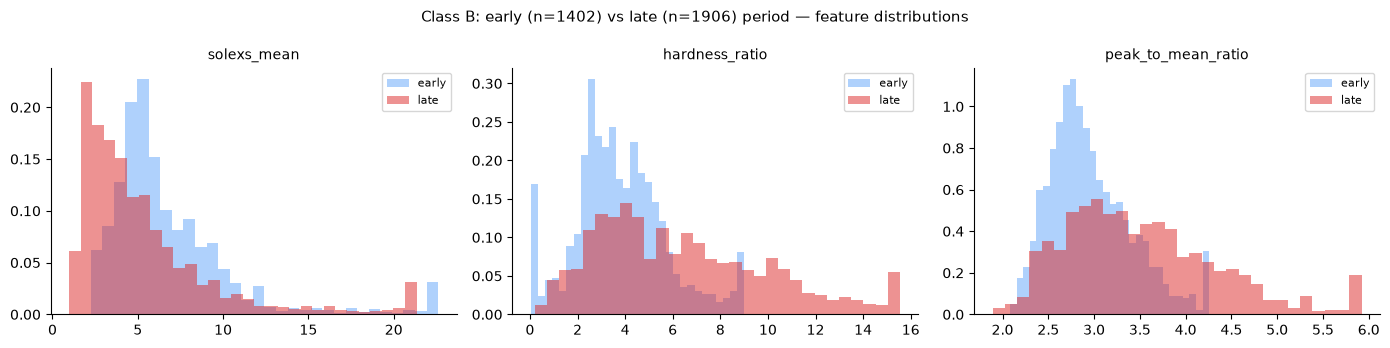


--- Class B: full feature comparison ---


,early_median,late_median,pct_change
solexs_mean,5.7456,4.1194,-28.3021
solexs_slope,0.0000,0.0000,NaN
solexs_std,2.5633,2.1518,-16.0546
hel1os_mean,22.9622,22.9806,0.0798
hel1os_slope,-0.0100,-0.0217,-116.6667
hardness_ratio,3.5589,5.7006,60.1800
hr_rate_of_change,0.0001,0.0002,137.9806
peak_to_mean_ratio,2.8714,3.3831,17.8180
hel1os_saturation_fraction,0.0000,0.0000,NaN


In [8]:
df_clean = df.dropna(subset=FEATURE_COLUMNS)
early = df_clean[df_clean.index < TRAIN_TEST_CUTOFF]
late = df_clean[df_clean.index >= TRAIN_TEST_CUTOFF]

for cls in ["M", "C", "X", "B"]:
    early_cls = early[early["label_letter"] == cls]
    late_cls = late[late["label_letter"] == cls]
    if len(early_cls) < 5 or len(late_cls) < 5:
        print(f"Class {cls}: insufficient data in one period (early n={len(early_cls)}, late n={len(late_cls)}) -- skipping")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    fig.suptitle(f"Class {cls}: early (n={len(early_cls)}) vs late (n={len(late_cls)}) period — feature distributions", fontsize=11)
    key_features = ["solexs_mean", "hardness_ratio", "peak_to_mean_ratio"]
    for ax, feat in zip(axes, key_features):
        ax.hist(early_cls[feat].clip(upper=early_cls[feat].quantile(0.98)), bins=30, alpha=0.5, label="early", color="#60A5FA", density=True)
        ax.hist(late_cls[feat].clip(upper=late_cls[feat].quantile(0.98)), bins=30, alpha=0.5, label="late", color="#DC2626", density=True)
        ax.set_title(feat, fontsize=10)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    comparison = pd.DataFrame({
        "early_median": early_cls[FEATURE_COLUMNS].median(),
        "late_median": late_cls[FEATURE_COLUMNS].median(),
    })
    comparison["pct_change"] = (
        (comparison["late_median"] - comparison["early_median"])
        / comparison["early_median"].abs().replace(0, np.nan) * 100
    )
    print(f"\n--- Class {cls}: full feature comparison ---")
    display(comparison.round(4))

## 4. QUIET Fraction Over Time

A broad sanity check for the same abrupt-vs-smooth question as Section 1,
looking at the dominant class directly.

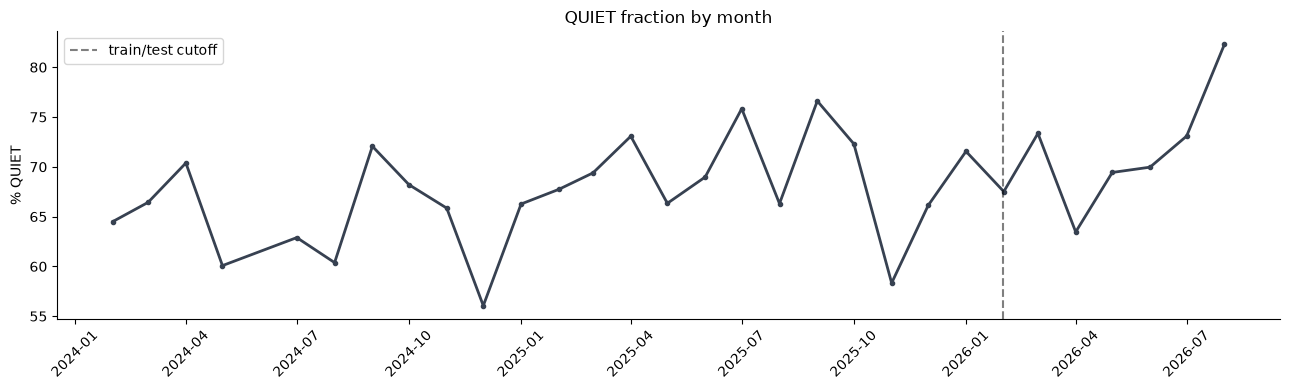

In [9]:
quiet_by_month = (df.groupby("year_month").apply(lambda g: (g["label_letter"] == "QUIET").mean() * 100))
quiet_by_month.index = quiet_by_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(quiet_by_month.index, quiet_by_month.values, color="#374151", linewidth=2, marker="o", markersize=3)
ax.axvline(cutoff_naive, color="black", linestyle="--", alpha=0.5, label="train/test cutoff")
ax.set_ylabel("% QUIET")
ax.set_title("QUIET fraction by month")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary

Fill in after reviewing the plots above:

- **Class frequency trend:** smooth / abrupt? (Section 1)
- **Data quality over time:** uniform / concentrated gaps? (Section 2)
- **Covariate shift:** do any classes show large `pct_change` values in
  Section 3? Which features, which classes?
- **Conclusion:** is this a genuine solar-cycle effect, a pipeline
  artifact, or something else — and does it support moving forward with
  the two-stage classifier, or does something need fixing first?

## 5. Investigating the NaN Spike Right Before the Cutoff

The monthly NaN-rate plot in Section 2 showed a sharp spike to ~30-32%
right before the train/test cutoff (Dec 2025 - Jan 2026). This section
pinpoints exactly which days and which feature columns are responsible,
to distinguish two real candidate causes:

- **Missing raw SoLEXS data** (the already-known 126-day gap) — would
  show up as NaN across ALL feature columns for those specific days.
- **HEL1OS saturation** (the confirmed CZT1 zero-readout issue) — would
  show up as NaN only in the HEL1OS-derived columns
  (`hel1os_mean`, `hel1os_slope`, `hardness_ratio`, `hr_rate_of_change`),
  while SoLEXS-only columns (`solexs_mean`, `solexs_slope`, `solexs_std`,
  `peak_to_mean_ratio`) stay populated.

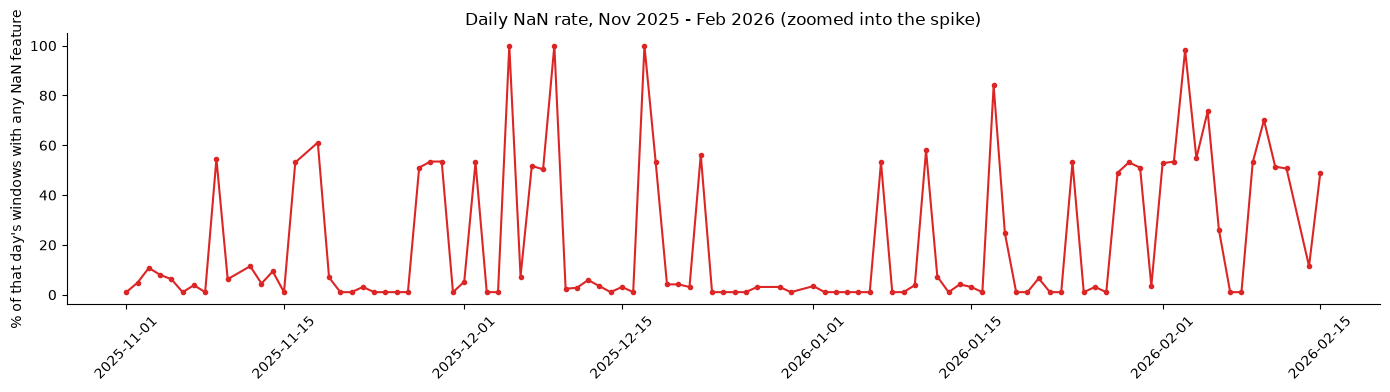

Worst 15 days by NaN rate in this window:


date
2025-12-09    100.000000
2025-12-05    100.000000
2025-12-17    100.000000
2026-02-03     98.263889
2026-01-17     84.027778
2026-02-05     73.611111
2026-02-10     70.138889
2025-11-18     61.111111
2026-01-11     57.986111
2025-12-22     56.250000
2026-02-04     54.861111
2025-11-09     54.513889
2025-11-28     53.472222
2026-02-02     53.472222
2025-11-29     53.472222
Name: any_nan, dtype: float64

In [17]:
# Zoom into the spike window at DAILY resolution (not monthly), to
# pinpoint the exact day(s) responsible rather than just the month.
spike_window = df.loc["2025-11-01":"2026-02-15"].copy()
spike_window["date"] = spike_window.index.date

daily_nan = spike_window.groupby("date")["any_nan"].mean() * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pd.to_datetime(daily_nan.index), daily_nan.values, color="#DC2626", linewidth=1.5, marker="o", markersize=3)
ax.set_ylabel("% of that day's windows with any NaN feature")
ax.set_title("Daily NaN rate, Nov 2025 - Feb 2026 (zoomed into the spike)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Worst 15 days by NaN rate in this window:")
daily_nan.sort_values(ascending=False).head(15)

In [18]:
# Per-FEATURE-COLUMN NaN rate within the spike window -- this is the
# key diagnostic. If SoLEXS columns and HEL1OS columns show similar
# NaN rates, it's likely raw missing data (affects everything equally).
# If HEL1OS columns are much higher than SoLEXS columns, it points to
# saturation specifically.
solexs_cols = ["solexs_mean", "solexs_slope", "solexs_std", "peak_to_mean_ratio"]
hel1os_cols = ["hel1os_mean", "hel1os_slope", "hardness_ratio", "hr_rate_of_change"]

per_col_nan = spike_window[FEATURE_COLUMNS].isna().mean() * 100
print("NaN rate per feature column, within the spike window (Nov 2025 - Feb 2026):")
display(per_col_nan.sort_values(ascending=False))

solexs_avg = per_col_nan[solexs_cols].mean()
hel1os_avg = per_col_nan[hel1os_cols].mean()
print(f"\nSoLEXS-only columns average NaN rate: {solexs_avg:.1f}%")
print(f"HEL1OS-derived columns average NaN rate: {hel1os_avg:.1f}%")
print(f"\n{'-> Points to HEL1OS saturation as the driver' if hel1os_avg > solexs_avg * 1.5 else '-> Points to raw missing data affecting everything equally' if abs(solexs_avg - hel1os_avg) < 5 else '-> Mixed signal, investigate further'}")

NaN rate per feature column, within the spike window (Nov 2025 - Feb 2026):


hr_rate_of_change             20.618873
hardness_ratio                19.281046
solexs_slope                  14.276961
hel1os_slope                  13.248911
solexs_mean                   12.956155
peak_to_mean_ratio            12.956155
solexs_std                    12.956155
hel1os_mean                   12.656590
hel1os_saturation_fraction     0.000000
dtype: float64


SoLEXS-only columns average NaN rate: 13.3%
HEL1OS-derived columns average NaN rate: 16.5%

-> Points to raw missing data affecting everything equally


In [19]:
# Cross-check the worst offending days against solexs_mean's own NaN
# status directly -- if solexs_mean itself is NaN on a given day, that
# day is very likely a genuinely missing-SoLEXS day (matches the known
# 126-day gap list). If solexs_mean is populated but hardness_ratio
# isn't, that's the saturation signature instead.
worst_days = daily_nan.sort_values(ascending=False).head(10).index

for d in worst_days:
    day_data = spike_window[spike_window["date"] == d]
    solexs_nan_pct = day_data["solexs_mean"].isna().mean() * 100
    hr_nan_pct = day_data["hardness_ratio"].isna().mean() * 100
    sat_frac_mean = day_data["hel1os_saturation_fraction"].mean()
    print(f"{d}: solexs_mean NaN={solexs_nan_pct:5.1f}%  hardness_ratio NaN={hr_nan_pct:5.1f}%  "
          f"avg saturation_fraction={sat_frac_mean:.3f}  "
          f"{'[LIKELY MISSING SOLEXS DAY]' if solexs_nan_pct > 50 else '[LIKELY SATURATION-DRIVEN]' if hr_nan_pct > 50 and solexs_nan_pct < 10 else '[MIXED/UNCLEAR]'}")

2025-12-09: solexs_mean NaN= 33.3%  hardness_ratio NaN= 99.0%  avg saturation_fraction=0.000  [MIXED/UNCLEAR]
2025-12-05: solexs_mean NaN= 49.7%  hardness_ratio NaN= 97.6%  avg saturation_fraction=0.000  [MIXED/UNCLEAR]
2025-12-17: solexs_mean NaN= 98.6%  hardness_ratio NaN= 98.6%  avg saturation_fraction=0.000  [LIKELY MISSING SOLEXS DAY]
2026-02-03: solexs_mean NaN= 94.8%  hardness_ratio NaN= 94.8%  avg saturation_fraction=0.000  [LIKELY MISSING SOLEXS DAY]
2026-01-17: solexs_mean NaN= 81.9%  hardness_ratio NaN= 81.9%  avg saturation_fraction=0.000  [LIKELY MISSING SOLEXS DAY]
2026-02-05: solexs_mean NaN= 63.5%  hardness_ratio NaN= 69.1%  avg saturation_fraction=0.006  [LIKELY MISSING SOLEXS DAY]
2026-02-10: solexs_mean NaN= 63.5%  hardness_ratio NaN= 63.5%  avg saturation_fraction=0.000  [LIKELY MISSING SOLEXS DAY]
2025-11-18: solexs_mean NaN= 11.1%  hardness_ratio NaN= 59.0%  avg saturation_fraction=0.000  [MIXED/UNCLEAR]
2026-01-11: solexs_mean NaN=  0.0%  hardness_ratio NaN= 55.2

### Cross-reference against the known 126-day missing-SoLEXS list

Paste your actual missing-days list below (from the earlier data-gap
investigation) to confirm directly whether the worst days above are
already-known gaps or something new.

In [20]:
# Paste your real missing-SoLEXS-days list here (from the earlier
# data-gap investigation) to check directly:
KNOWN_MISSING_DAYS = pd.to_datetime([
    "2024-03-27",
    "2024-03-28",
    "2024-03-30",
    "2024-06-01",
    "2024-06-02",
    "2024-06-03",
    "2024-06-04",
    "2024-06-05",
    "2024-06-06",
    "2024-06-07",
    "2024-06-08",
    "2024-06-09",
    "2024-06-10",
    "2024-06-11",
    "2024-06-12",
    "2024-06-13",
    "2024-06-14",
    "2024-06-15",
    "2024-06-16",
    "2024-06-17",
    "2024-06-18",
    "2024-06-19",
    "2024-06-20",
    "2024-06-21",
    "2024-06-22",
    "2024-06-23",
    "2024-06-24",
    "2024-06-25",
    "2024-06-26",
    "2024-06-27",
    "2024-06-28",
    "2024-06-29",
    "2024-06-30",
    "2024-07-02",
    "2024-08-29",
    "2024-09-09",
    "2024-09-24",
    "2024-10-12",
    "2024-11-06",
    "2024-12-22",
    "2024-12-23",
    "2024-12-26",
    "2024-12-27",
    "2025-01-12",
    "2025-01-13",
    "2025-01-21",
    "2025-01-27",
    "2025-01-29",
    "2025-01-30",
    "2025-02-03",
    "2025-02-04",
    "2025-02-05",
    "2025-02-06",
    "2025-02-07",
    "2025-03-02",
    "2025-03-05",
    "2025-03-14",
    "2025-03-16",
    "2025-03-21",
    "2025-04-06",
    "2025-04-07",
    "2025-04-16",
    "2025-04-28",
    "2025-04-29",
    "2025-05-01",
    "2025-05-02",
    "2025-05-05",
    "2025-05-06",
    "2025-05-12",
    "2025-05-15",
    "2025-05-20",
    "2025-05-21",
    "2025-05-25",
    "2025-06-07",
    "2025-06-10",
    "2025-06-11",
    "2025-06-22",
    "2025-06-24",
    "2025-07-02",
    "2025-07-03",
    "2025-07-05",
    "2025-07-06",
    "2025-07-11",
    "2025-07-12",
    "2025-07-13",
    "2025-07-17",
    "2025-07-20",
    "2025-07-21",
    "2025-07-22",
    "2025-07-23",
    "2025-07-24",
    "2025-07-25",
    "2025-07-26",
    "2025-07-27",
    "2025-08-05",
    "2025-08-14",
    "2025-08-15",
    "2025-08-23",
    "2025-08-26",
    "2025-08-31",
    "2025-09-14",
    "2025-09-21",
    "2025-09-22",
    "2025-09-24",
    "2025-09-26",
    "2025-09-27",
    "2025-09-28",
    "2025-09-29",
    "2025-10-16",
    "2025-10-24",
    "2025-10-29",
    "2025-10-30",
    "2025-11-11",
    "2025-11-17",
    "2025-12-28",
    "2025-12-31",
    "2026-02-13",
    "2026-02-17",
    "2026-02-20",
    "2026-04-16",
    "2026-04-17",
    "2026-04-23",
    "2026-04-29",
    "2026-05-22",
    "2026-06-04",
    "2026-06-09"

]).date

worst_days_set = set(worst_days)
known_missing_set = set(KNOWN_MISSING_DAYS)
overlap = worst_days_set & known_missing_set

print(f"Of the 10 worst NaN-rate days in the spike window:")
print(f"  {len(overlap)} are already-known missing-SoLEXS days: {sorted(overlap)}")
print(f"  {len(worst_days_set - known_missing_set)} are NEW, not previously flagged: {sorted(worst_days_set - known_missing_set)}")

Of the 10 worst NaN-rate days in the spike window:
  0 are already-known missing-SoLEXS days: []
  10 are NEW, not previously flagged: [datetime.date(2025, 11, 18), datetime.date(2025, 12, 5), datetime.date(2025, 12, 9), datetime.date(2025, 12, 17), datetime.date(2025, 12, 22), datetime.date(2026, 1, 11), datetime.date(2026, 1, 17), datetime.date(2026, 2, 3), datetime.date(2026, 2, 5), datetime.date(2026, 2, 10)]
